### 1.4.5.2. Driven Motion and Resonance

$$
\frac{d^2x}{dt^2} + 2\lambda\frac{dx}{dt} + \omega^2 x = F(t), \qquad
x(t) = \underbrace{x_c(t)}_{\text{transient}} + \underbrace{x_p(t)}_{\text{steady-state}} .
$$

**Explanation:**

An external force adds a forcing term $F(t)$, making the oscillator equation nonhomogeneous; the solution splits into the complementary $x_c$ and a particular $x_p$ found by [undetermined coefficients](../04_Higher_Order_Linear_Equations/04_undetermined_coefficients.ipynb) or [variation of parameters](../04_Higher_Order_Linear_Equations/05_variation_of_parameters.ipynb). With damping, $x_c \to 0$, so it is the **transient** part and the periodic $x_p$ is the **steady-state** response — the initial conditions are forgotten. With *no* damping and a forcing frequency $\gamma$ equal to the natural frequency $\omega$, **pure resonance** occurs: the amplitude grows without bound (proportional to $t$). Resonance and the transient/steady-state split are central to the frequency-response view of control systems.

**Intuition:**

<p align="center">
  <img src="../../../Figures/01040502_pure_resonance.jpeg"
       alt="Pure resonance: oscillation whose amplitude grows linearly with time"
       width="300">
</p>

**Numerical Example:**

Solve $\tfrac15 x'' + 1.2x' + 2x = 5\cos 4t$, $x(0) = \tfrac12$, $x'(0) = 0$ (mass $\tfrac15$, $k = 2$, damping $1.2$, periodic drive).

**Step 1 — clear the fraction.** Multiply by 5: $x'' + 6x' + 10x = 25\cos 4t$.

**Step 2 — transient $x_c$.** Auxiliary $m^2 + 6m + 10 = 0$ gives $m = -3 \pm i$, so $x_c = e^{-3t}(c_1\cos t + c_2\sin t)$, which decays.

**Step 3 — steady-state $x_p$.** Try $x_p = A\cos 4t + B\sin 4t$. Substituting gives $(-6A + 24B)\cos 4t + (-24A - 6B)\sin 4t = 25\cos 4t$, so $-6A + 24B = 25$, $-24A - 6B = 0$, yielding $A = -\tfrac{25}{102}$, $B = \tfrac{50}{51}$.

**Step 4 — apply initial conditions** to $x = x_c + x_p$: $x(0) = \tfrac12$ gives $c_1 = \tfrac{38}{51}$, and $x'(0) = 0$ gives $c_2 = -\tfrac{86}{51}$. Hence

$$
x(t) = \underbrace{e^{-3t}\!\left(\tfrac{38}{51}\cos t - \tfrac{86}{51}\sin t\right)}_{\text{transient} \to 0}
+ \underbrace{\left(-\tfrac{25}{102}\cos 4t + \tfrac{50}{51}\sin 4t\right)}_{\text{steady-state}} .
$$

In [1]:
import sympy as sp

t = sp.symbols("t")
x = sp.Function("x")

equation = sp.Eq(x(t).diff(t, 2) + 6 * x(t).diff(t) + 10 * x(t), 25 * sp.cos(4 * t))
transient = sp.dsolve(sp.Eq(x(t).diff(t, 2) + 6 * x(t).diff(t) + 10 * x(t), 0), x(t)).rhs
full = sp.dsolve(equation, x(t), ics={x(0): sp.Rational(1, 2), x(t).diff(t).subs(t, 0): 0})

steady_state = sp.expand(full.rhs - full.rhs.coeff(sp.exp(-3 * t)) * sp.exp(-3 * t))
print("complementary (transient form):", transient)
print("full solution x(t) =", full.rhs)
print("steady-state x_p(t) =", sp.nsimplify(steady_state))

complementary (transient form): (C1*sin(t) + C2*cos(t))*exp(-3*t)
full solution x(t) = (-86*sin(t)/51 + 38*cos(t)/51)*exp(-3*t) + 50*sin(4*t)/51 - 25*cos(4*t)/102
steady-state x_p(t) = 50*sin(4*t)/51 - 25*cos(4*t)/102


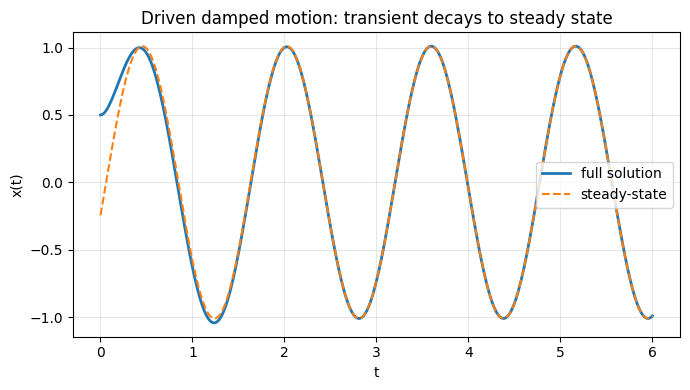

In [2]:
import numpy as np
import matplotlib.pyplot as plt

time = np.linspace(0, 6, 400)
transient = np.exp(-3 * time) * (38 / 51 * np.cos(time) - 86 / 51 * np.sin(time))
steady_state = -25 / 102 * np.cos(4 * time) + 50 / 51 * np.sin(4 * time)

plt.figure(figsize=(7, 4))
plt.plot(time, transient + steady_state, linewidth=2, label="full solution")
plt.plot(time, steady_state, "--", label="steady-state")
plt.xlabel("t"); plt.ylabel("x(t)"); plt.title("Driven damped motion: transient decays to steady state")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

**References:**

[📘 Zill, D. G. (2016). *A First Course in Differential Equations with Modeling Applications* (11th ed.). Cengage Learning.](https://www.cengage.com/c/a-first-course-in-differential-equations-with-modeling-applications-11e-zill/9781305965720/)

---

[⬅️ Previous: Free Spring/Mass Systems](./01_free_spring_mass_systems.ipynb) | [Next: LRC Series Circuits ➡️](./03_lrc_series_circuits.ipynb)